In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv('OnlineRetail_clean.csv', encoding='ISO-8859-1')

print(df.shape)
print(df.columns)

df.head()

Saving OnlineRetail_clean.csv to OnlineRetail_clean.csv
(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv('OnlineRetail_clean.csv', encoding='ISO-8859-1')

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Total Price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [6]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,1


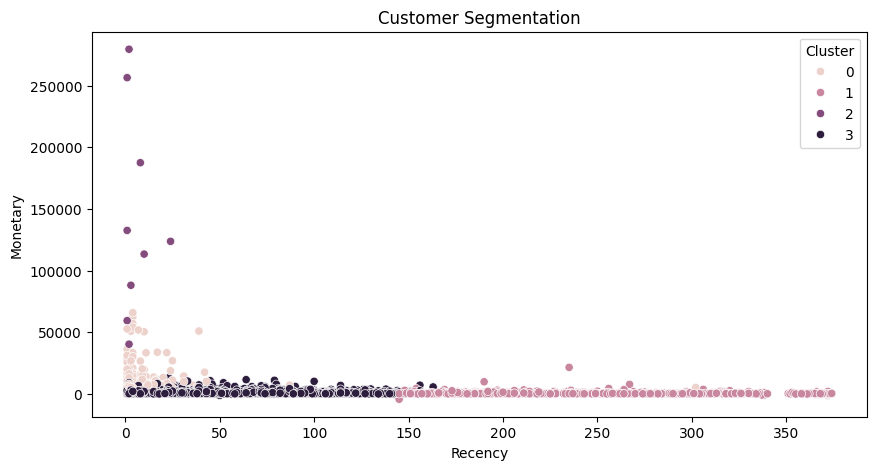

In [8]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=rfm['Recency'], y=rfm['Monetary'], hue=rfm['Cluster'])
plt.title('Customer Segmentation')
plt.show()

In [9]:
rfm['Churn'] = np.where(rfm['Recency'] > 90, 1, 0)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Churn
CustomerID,,,,,
12346.0,326,2,0.00,1,1
12347.0,2,7,4310.00,3,0
12348.0,75,4,1797.24,3,0
12349.0,19,1,1757.55,3,0
12350.0,310,1,334.40,1,1


In [10]:
X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [11]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00       594
           1       1.00      1.00      1.00       281

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875



In [12]:
import io
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from google.colab import files # Import files for upload

# --- Start: Ensure file is available and re-create rfm DataFrame for self-contained execution ---
# Prompt user to upload the file if it's not present
# This makes the cell self-contained for file access.
# Note: This will open a file upload dialog when executed.
print("Please upload the 'OnlineRetail_clean.csv' file.")
uploaded = files.upload()

# Assuming the user uploads 'OnlineRetail_clean.csv'
# If the file is uploaded, it will be saved to the current directory.

# Re-load and preprocess df
df = pd.read_csv('OnlineRetail_clean.csv', encoding='ISO-8859-1')
df = df.dropna(subset=['CustomerID'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Calculate RFM
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Scale RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Apply KMeans and add Cluster (assuming 4 clusters based on previous notebook state)
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto') # Added n_init='auto' for KMeans v1.2+
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Add Churn based on Recency
rfm['Churn'] = np.where(rfm['Recency'] > 90, 1, 0)
# --- End: Re-creating rfm DataFrame ---

# Now X and y can be defined
X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Get the dictionary output for easier conversion to DataFrame
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert the dictionary to a pandas DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Round the numerical columns for a cleaner look
# Exclude 'support' column from rounding as it represents counts
columns_to_round = ['precision', 'recall', 'f1-score']
report_df[columns_to_round] = report_df[columns_to_round].round(2)

display(report_df)

Please upload the 'OnlineRetail_clean.csv' file.


Saving OnlineRetail_clean.csv to OnlineRetail_clean (1).csv


,precision,recall,f1-score,support
0,1.0,1.0,1.0,594.0
1,1.0,1.0,1.0,281.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,875.0
weighted avg,1.0,1.0,1.0,875.0


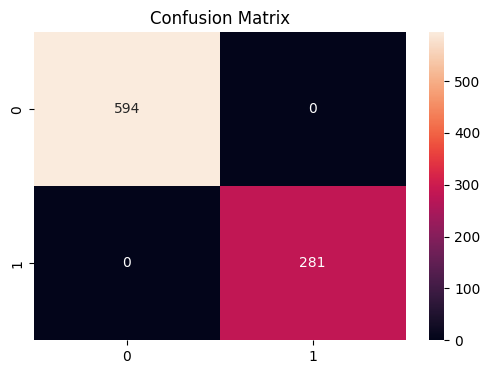

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d')

plt.title('Confusion Matrix')
plt.show()

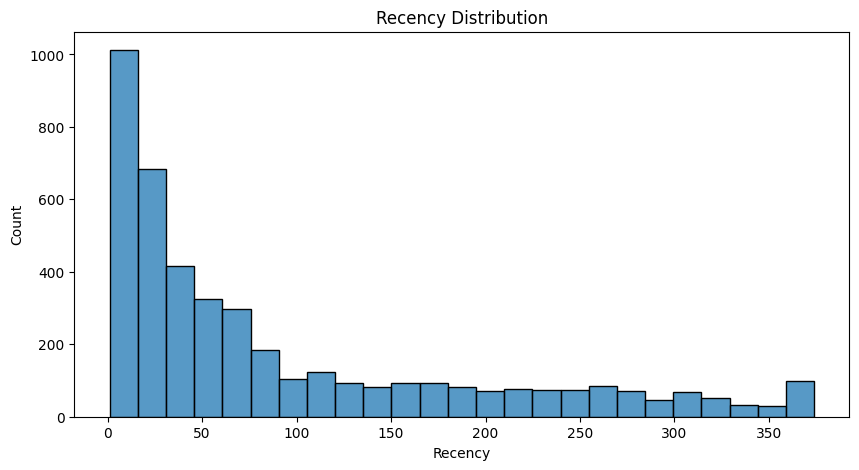

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(rfm['Recency'])
plt.title('Recency Distribution')
plt.show()

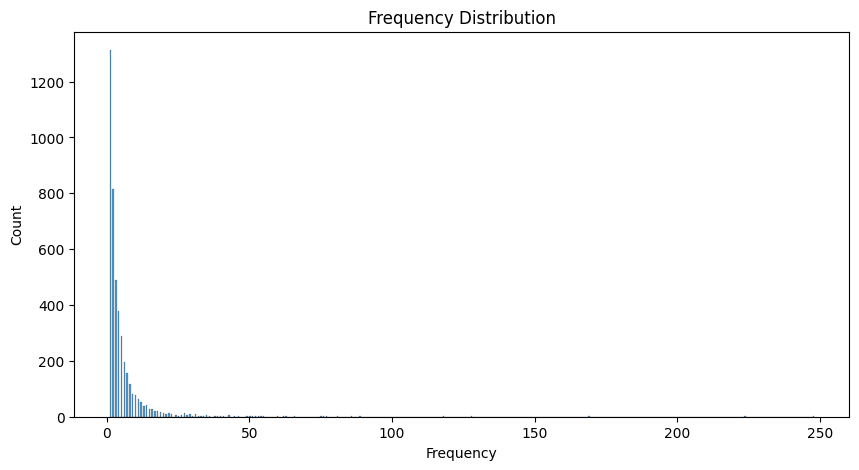

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(rfm['Frequency'])
plt.title('Frequency Distribution')
plt.show()

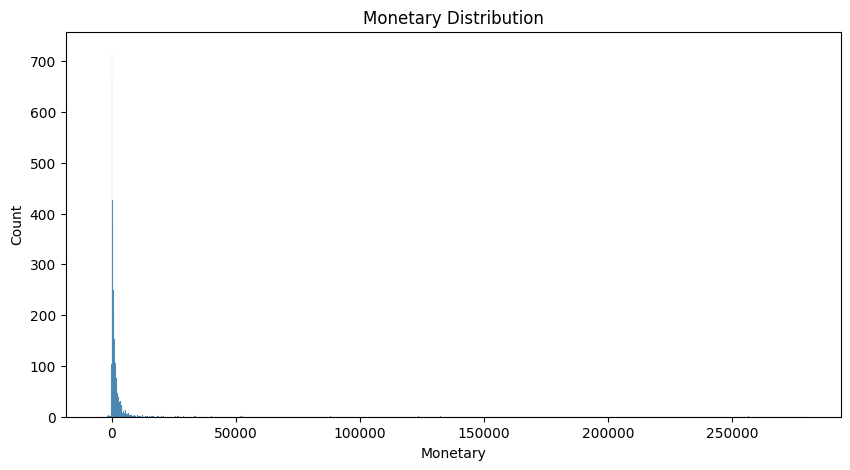

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(rfm['Monetary'])
plt.title('Monetary Distribution')
plt.show()

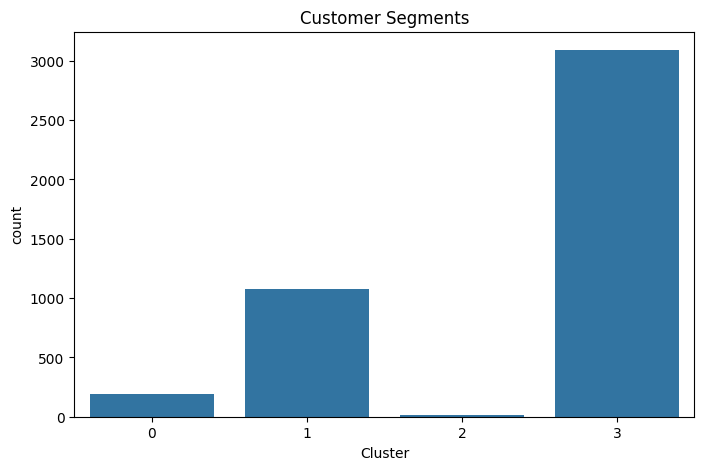

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x=rfm['Cluster'])
plt.title('Customer Segments')
plt.show()

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


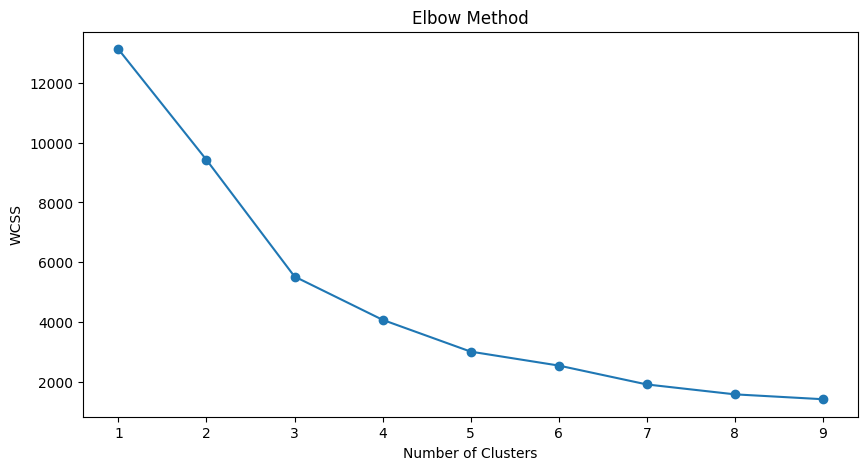

In [19]:
wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1,10), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [20]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary,Churn
Cluster,,,,
0,10.752577,28.510309,12168.264691,0.005155
1,248.927577,1.805942,455.110716,1.000000
2,5.090909,109.909091,124312.306364,0.000000
3,42.780906,4.370550,1320.981506,0.121683


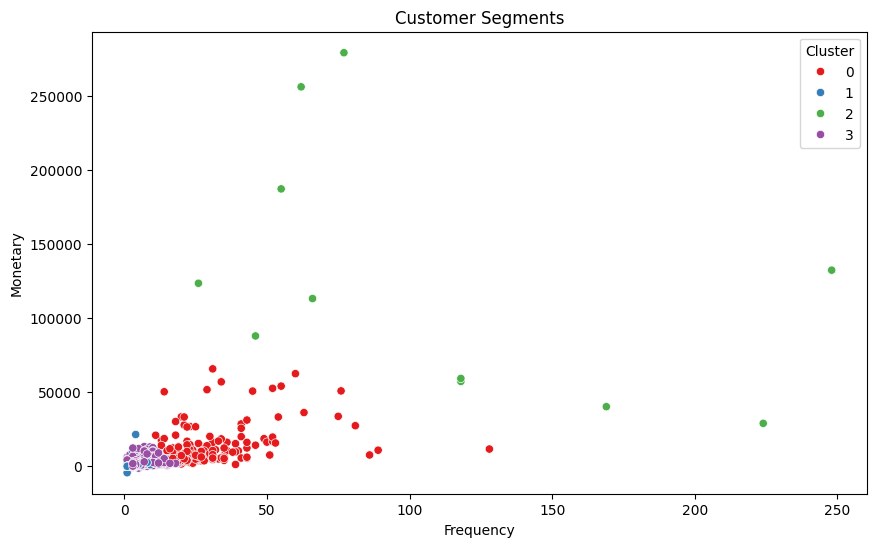

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster'],
    palette='Set1'
)

plt.title('Customer Segments')
plt.show()

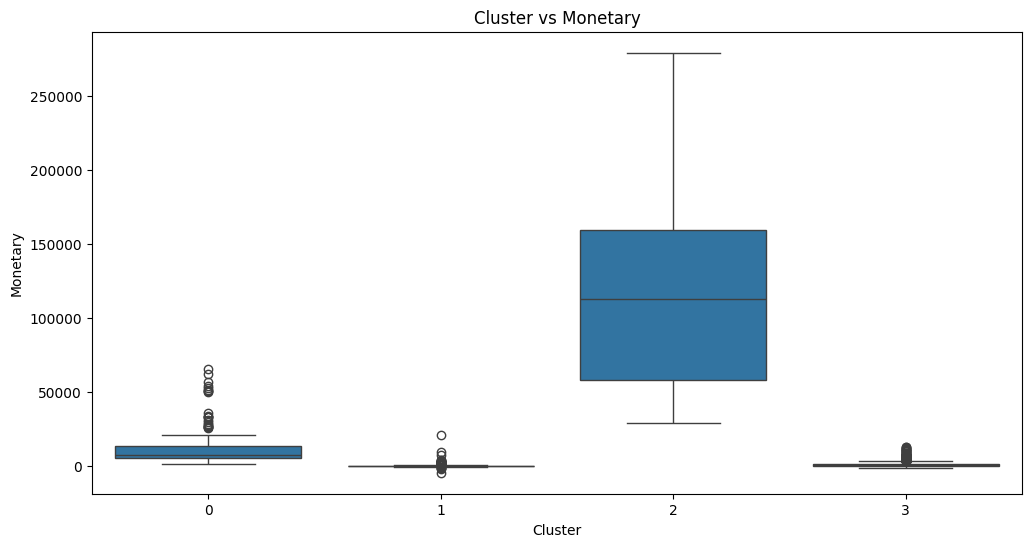

In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Cluster', y='Monetary', data=rfm)
plt.title('Cluster vs Monetary')
plt.show()


In [23]:
def customer_segment(row):
    if row['Cluster'] == 0:
        return 'Loyal Customers'
    elif row['Cluster'] == 1:
        return 'New Customers'
    elif row['Cluster'] == 2:
        return 'Potential Customers'
    else:
        return 'At Risk Customers'

rfm['CustomerType'] = rfm.apply(customer_segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Churn,CustomerType
CustomerID,,,,,,
12346.0,326,2,0.00,1,1,New Customers
12347.0,2,7,4310.00,3,0,At Risk Customers
12348.0,75,4,1797.24,3,0,At Risk Customers
12349.0,19,1,1757.55,3,0,At Risk Customers
12350.0,310,1,334.40,1,1,New Customers


In [24]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

importance

,Feature,Importance
0,Recency,2.144756
1,Frequency,0.527992
2,Monetary,-0.001888


In [25]:

rfm.to_csv('Final_Customer_Segmentation.csv')